# Lab 9: Data Visualization in Python with Matplotlib and Seaborn


### Topic: Expanding Plotting Skills for Experimental Data

To begin, create a copy of this file using File -> Save as... and name the new file "Lab_9_LastName_FirstName.ipynb" using your last and first name.  Make sure to execute all the code cells in the notebook and that the outputs show in your report. *Two points are allocated for reading and running the code blocks*. Before submitting, remember to add a collaboration statement in this mark down indicating the contribution of each member. You may edit the template below:

- Group member 1 first name, last name & student id: contributions here
- Group member 2 first name, last name & student id: contributions here
- if applicable, Group member 3 first name, last name & student id: contributions here

---

## Purpose of This Lab

In this lab, you will build on your earlier work with **Pandas** and **Matplotlib** and then begin using **Seaborn**, another popular Python plotting library.

These libraries are widely used in science, engineering, healthcare, business, and data analysis to turn raw numbers into clear visual summaries.

By the end of this lab, you should be more comfortable creating graphs, labeling them, and choosing an appropriate plot type for your data.


# Section 1: Plotting Libraries for Python

By the end of this section, you should understand how to:

- import the libraries needed for plotting
- review basic Matplotlib usage
- create line plots, bar charts, histograms, and scatter plots
- improve graph readability with titles and axis labels
- understand what Seaborn is and how it relates to Matplotlib
- create Seaborn plots from a DataFrame

These are foundational graphing skills you will use often in later labs and projects. Matplotlib and seaborn are automatically installed with Anaconda. You can click the cell below to do a library check for this lab.


In [3]:
try:
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    print(" pandas loaded successfully")
    print(" matplotlib loaded successfully")
    print(" seaborn loaded successfully")
except Exception as e:
    print("Import error:", e)


 pandas loaded successfully
 matplotlib loaded successfully
 seaborn loaded successfully


If you are working with barebones conda without Anaconda or using pip to manage packages, refer to the documentations for installation instructions for your platform. You can find the installation instructions for matplotlib at https://matplotlib.org/stable/install/index.html and for seaborn at https://seaborn.pydata.org/installing.html



## What is the difference between Matplotlib and Seaborn?

### Matplotlib
Matplotlib is one of the main graphing libraries in Python. It gives you a lot of control over how a graph looks.

### Seaborn
Seaborn is built on top of Matplotlib. It works especially well with **pandas DataFrames** and often creates polished statistical plots with fewer lines of code.

A simple way to think about them is:

- **Matplotlib** = flexible, foundational plotting library
- **Seaborn** = higher-level plotting library that uses Matplotlib underneath


## An Example Dataset

To practice graphing, we will use a small **enzyme activity** dataset. Imagine a lab is testing enzyme activity at different temperatures and pH conditions.

### Column meanings
- **Sample_ID**: unique sample label
- **Temperature_C**: incubation temperature in degrees Celsius
- **pH**: pH condition
- **Reaction_Time_min**: reaction time in minutes
- **Absorbance_450**: plate-reader absorbance signal
- **Condition**: experimental condition label


In [4]:
enzyme_data = {
    "Sample_ID": ["S1","S2","S3","S4","S5","S6","S7","S8","S9","S10","S11","S12"],
    "Temperature_C": [20,20,20,25,25,25,30,30,30,35,35,35],
    "pH": [6.0,7.0,8.0,6.0,7.0,8.0,6.0,7.0,8.0,6.0,7.0,8.0],
    "Reaction_Time_min": [5,5,5,10,10,10,15,15,15,20,20,20],
    "Absorbance_450": [0.21,0.34,0.28,0.40,0.55,0.48,0.58,0.76,0.69,0.51,0.72,0.61],
    "Condition": ["Low_pH","Neutral","High_pH","Low_pH","Neutral","High_pH",
                  "Low_pH","Neutral","High_pH","Low_pH","Neutral","High_pH"]
}

df = pd.DataFrame(enzyme_data)
df


,Sample_ID,Temperature_C,pH,Reaction_Time_min,Absorbance_450,Condition
0,S1,20,6.0,5,0.21,Low_pH
1,S2,20,7.0,5,0.34,Neutral
2,S3,20,8.0,5,0.28,High_pH
3,S4,25,6.0,10,0.40,Low_pH
4,S5,25,7.0,10,0.55,Neutral
5,S6,25,8.0,10,0.48,High_pH
6,S7,30,6.0,15,0.58,Low_pH
7,S8,30,7.0,15,0.76,Neutral
8,S9,30,8.0,15,0.69,High_pH
9,S10,35,6.0,20,0.51,Low_pH


# Section 1: Review of Basic Matplotlib Workflow

A common Matplotlib workflow looks like this:

1. choose the data to plot  
2. choose a plot type  
3. add a title  
4. label the axes  
5. display the graph with `plt.show()`

We will now walk through several common graph types.


## Example 1: Line Plot

A **line plot** is useful when you want to show change across an ordered variable such as time, temperature, or trial number.


In [5]:
avg_by_temp = df.groupby("Temperature_C")["Absorbance_450"].mean()
avg_by_temp


Temperature_C
20    0.276667
25    0.476667
30    0.676667
35    0.613333
Name: Absorbance_450, dtype: float64

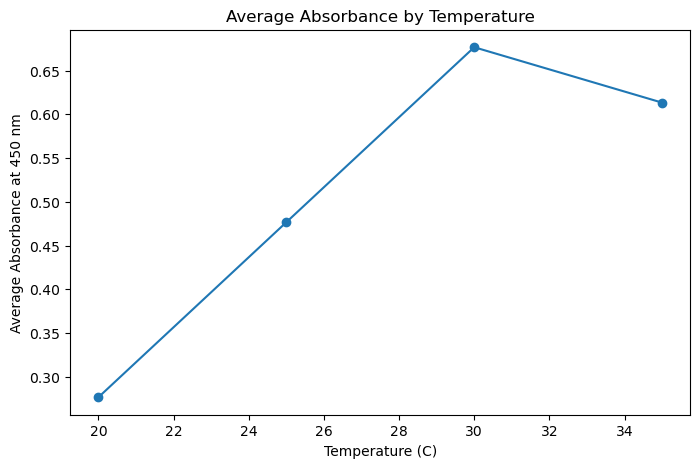

In [6]:
plt.figure(figsize=(8,5))
plt.plot(avg_by_temp.index, avg_by_temp.values, marker="o")
plt.title("Average Absorbance by Temperature")
plt.xlabel("Temperature (C)")
plt.ylabel("Average Absorbance at 450 nm")
plt.show()


## What is happening here?

### `groupby("Temperature_C")["Absorbance_450"].mean()`
This calculates the average absorbance for each temperature.

### `plt.plot(...)`
This creates the line plot.

### `marker="o"`
This places a dot at each plotted value.

### `plt.title(...)`, `plt.xlabel(...)`, and `plt.ylabel(...)`
These make the graph easier to read and interpret.


## Example 2: Bar Chart

A **bar chart** is useful when you want to compare categories.

Here, we will compare the average absorbance for each experimental condition.


In [7]:
avg_by_condition = df.groupby("Condition")["Absorbance_450"].mean()
avg_by_condition


Condition
High_pH    0.5150
Low_pH     0.4250
Neutral    0.5925
Name: Absorbance_450, dtype: float64

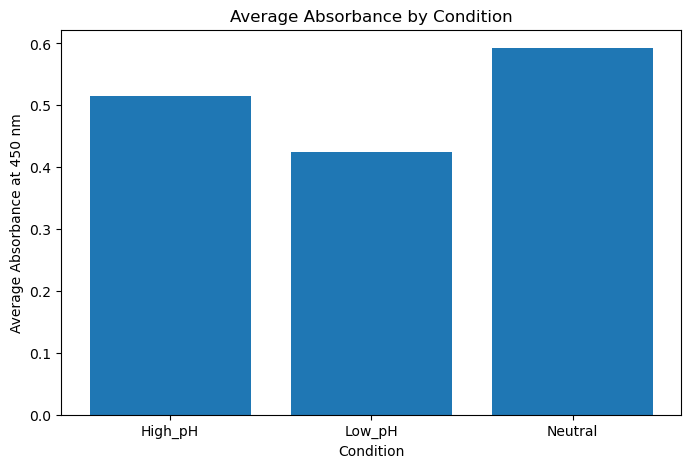

In [8]:
plt.figure(figsize=(8,5))
plt.bar(avg_by_condition.index, avg_by_condition.values)
plt.title("Average Absorbance by Condition")
plt.xlabel("Condition")
plt.ylabel("Average Absorbance at 450 nm")
plt.show()


## Example 3: Histogram

A **histogram** shows the distribution of a numerical variable.

Here, we will look at the distribution of absorbance values.


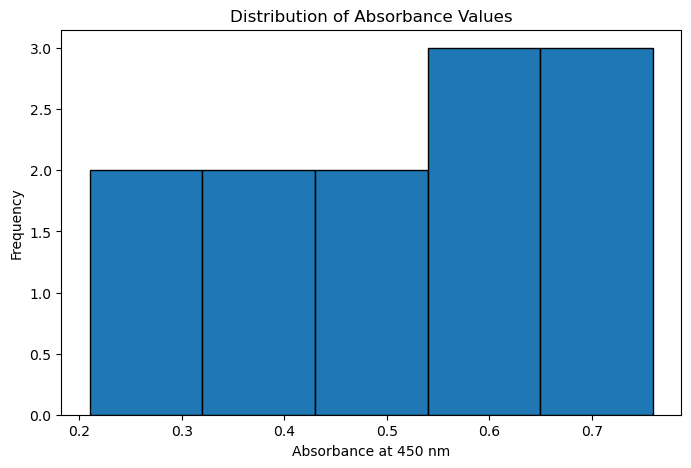

In [9]:
plt.figure(figsize=(8,5))
plt.hist(df["Absorbance_450"], bins=5, edgecolor="black")
plt.title("Distribution of Absorbance Values")
plt.xlabel("Absorbance at 450 nm")
plt.ylabel("Frequency")
plt.show()


## Example 4: Scatter Plot

A **scatter plot** helps you examine the relationship between two numerical variables.

Here, we will compare `Reaction_Time_min` and `Absorbance_450`.


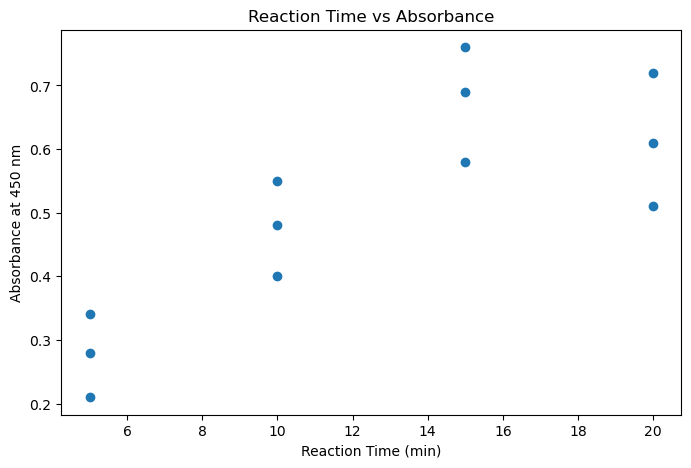

In [10]:
plt.figure(figsize=(8,5))
plt.scatter(df["Reaction_Time_min"], df["Absorbance_450"])
plt.title("Reaction Time vs Absorbance")
plt.xlabel("Reaction Time (min)")
plt.ylabel("Absorbance at 450 nm")
plt.show()


## Helpful Matplotlib tools to remember

Some very common Matplotlib functions are:

- `plt.figure(figsize=(width, height))`
- `plt.plot(...)`
- `plt.bar(...)`
- `plt.hist(...)`
- `plt.scatter(...)`
- `plt.title(...)`
- `plt.xlabel(...)`
- `plt.ylabel(...)`
- `plt.show()`

For beginner graphing, these are often enough.


# Section 2: Expanding Matplotlib Usage

Now we will build on the basics and make graphs a little more informative.

We can improve graphs by:

- choosing a better figure size
- rotating crowded labels
- changing marker styles
- adding grid lines
- plotting more than one series when appropriate


## Example 5: Line Plot with a Grid

Grid lines can make values easier to read.


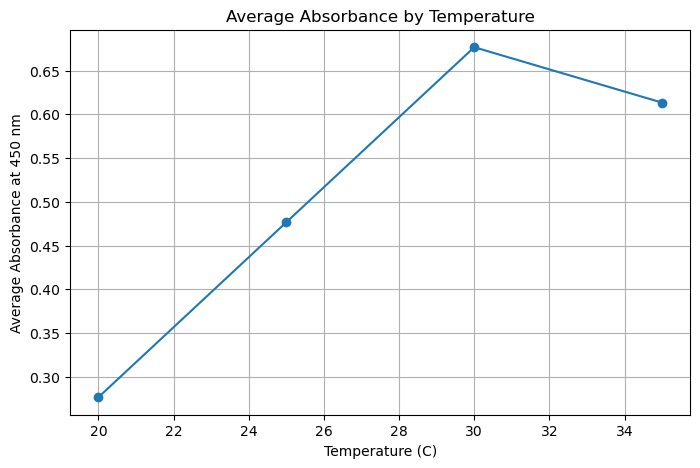

In [11]:
plt.figure(figsize=(8,5))
plt.plot(avg_by_temp.index, avg_by_temp.values, marker="o")
plt.title("Average Absorbance by Temperature")
plt.xlabel("Temperature (C)")
plt.ylabel("Average Absorbance at 450 nm")
plt.grid(True)
plt.show()


## Example 6: Bar Chart with Rotated Labels

If category names are long, rotating labels can improve readability.


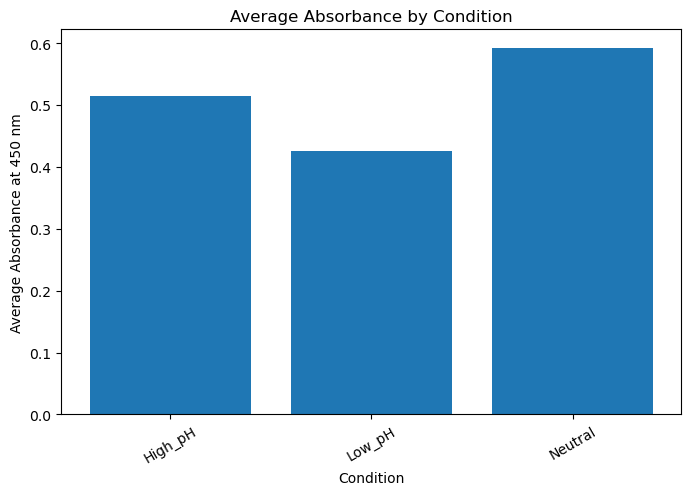

In [12]:
plt.figure(figsize=(8,5))
plt.bar(avg_by_condition.index, avg_by_condition.values)
plt.title("Average Absorbance by Condition")
plt.xlabel("Condition")
plt.ylabel("Average Absorbance at 450 nm")
plt.xticks(rotation=30)
plt.show()


## Example 7: Plotting two numerical columns against the same x-axis

Below, we summarize the average reaction time and average absorbance by condition. The values are not on the same scale, so this graph is mainly for practicing plotting multiple series.


In [13]:
summary_df = df.groupby("Condition")[["Reaction_Time_min", "Absorbance_450"]].mean()
summary_df


,Reaction_Time_min,Absorbance_450
Condition,,
High_pH,12.5,0.5150
Low_pH,12.5,0.4250
Neutral,12.5,0.5925


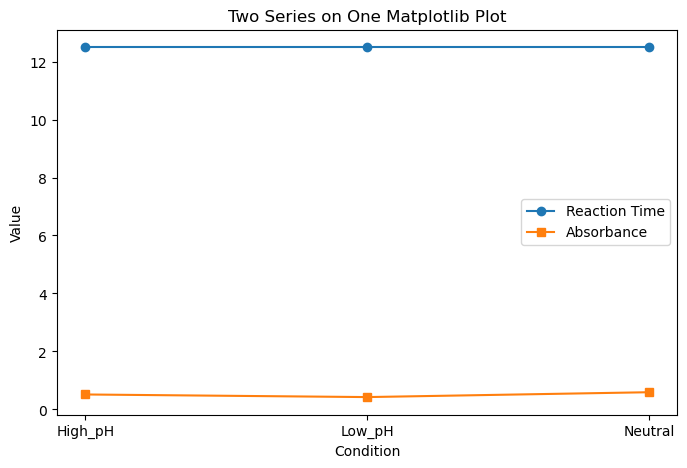

In [14]:
plt.figure(figsize=(8,5))
plt.plot(summary_df.index, summary_df["Reaction_Time_min"], marker="o", label="Reaction Time")
plt.plot(summary_df.index, summary_df["Absorbance_450"], marker="s", label="Absorbance")
plt.title("Two Series on One Matplotlib Plot")
plt.xlabel("Condition")
plt.ylabel("Value")
plt.legend()
plt.show()


## When should you use each plot type?

- **Line plot**: trends across an ordered variable
- **Bar chart**: comparing categories
- **Histogram**: understanding the spread of one numerical variable
- **Scatter plot**: relationship between two numerical variables

Choosing the right plot type is part of good data communication.


# Section 3: Introduction to Seaborn

Seaborn is another Python plotting library that works very well with pandas DataFrames.

A few advantages of Seaborn are:

- it directly uses column names from a DataFrame
- it often takes fewer lines of code
- many default graphs look polished right away
- it includes useful statistical graph types


## Set a Seaborn theme

This changes the visual style of the plots.


In [15]:
sns.set_theme()

## Example 8: Seaborn Scatter Plot

Notice that Seaborn lets us pass the full DataFrame and then specify column names with `x=` and `y=`.


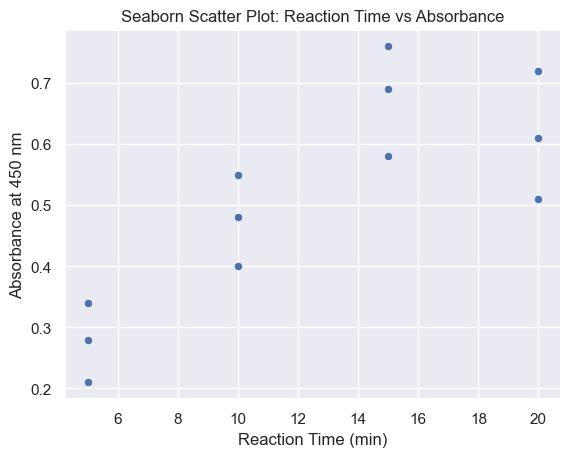

In [16]:
sns.scatterplot(data=df, x="Reaction_Time_min", y="Absorbance_450")
plt.title("Seaborn Scatter Plot: Reaction Time vs Absorbance")
plt.xlabel("Reaction Time (min)")
plt.ylabel("Absorbance at 450 nm")
plt.show()


## Example 9: Seaborn Bar Plot

We can use Seaborn to compare absorbance across conditions.


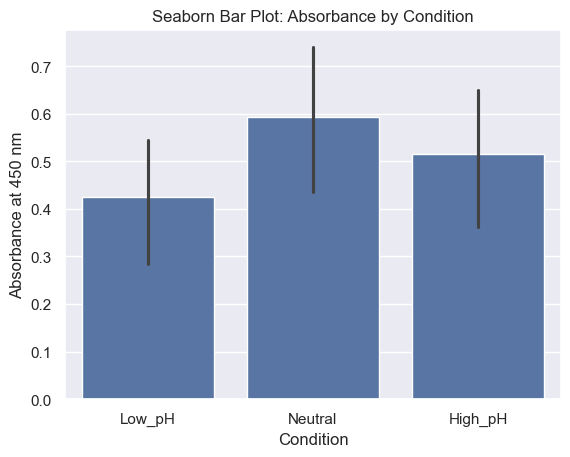

In [17]:
sns.barplot(data=df, x="Condition", y="Absorbance_450")
plt.title("Seaborn Bar Plot: Absorbance by Condition")
plt.xlabel("Condition")
plt.ylabel("Absorbance at 450 nm")
plt.show()


## Example 10: Seaborn Histogram

Seaborn also supports histograms using `histplot`.


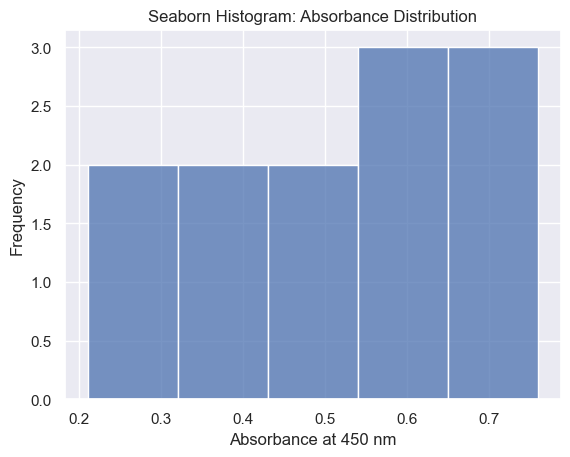

In [18]:
sns.histplot(data=df, x="Absorbance_450", bins=5)
plt.title("Seaborn Histogram: Absorbance Distribution")
plt.xlabel("Absorbance at 450 nm")
plt.ylabel("Frequency")
plt.show()


## Example 11: Seaborn Box Plot

A **box plot** helps summarize the spread of data and compare groups.

Here, we compare absorbance values across conditions.


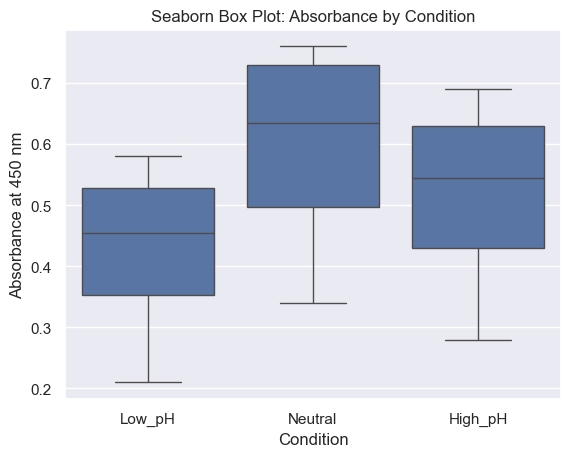

In [19]:
sns.boxplot(data=df, x="Condition", y="Absorbance_450")
plt.title("Seaborn Box Plot: Absorbance by Condition")
plt.xlabel("Condition")
plt.ylabel("Absorbance at 450 nm")
plt.show()


The horizontal line inside the boxes correspond to the median. The box bounds the so-called inter-quartile range (IQR). The upper limit of the IQR is the 75 percentile, meaning that 75% of the values are below this value. The lower limit of the IQR is the 25 percentile, meaning that 25% of the values are below this value. Thus, 50% of the data is in the IQR. The whiskers outside the box indicate the limit for outliers.

## Example 12: Seaborn Scatter Plot with `hue`

One especially useful Seaborn feature is `hue`, which colors points by category.


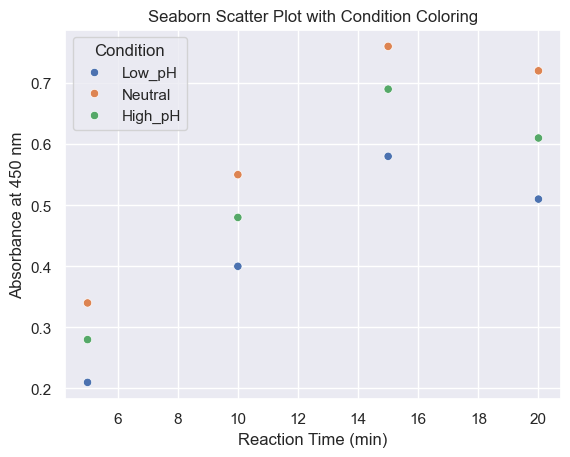

In [20]:
sns.scatterplot(data=df, x="Reaction_Time_min", y="Absorbance_450", hue="Condition")
plt.title("Seaborn Scatter Plot with Condition Coloring")
plt.xlabel("Reaction Time (min)")
plt.ylabel("Absorbance at 450 nm")
plt.show()


## What does `hue` do?

In Seaborn, `hue` separates points or bars by a category using different colors.

That can make it easier to see whether different groups behave differently in the same graph.


# Section 4: Matplotlib vs Seaborn

You do not need to think of these as competing libraries. In practice, many people use them together.

### Matplotlib is useful when:
- you want direct control over the graph
- you want to build a graph step by step
- you want to customize details manually

### Seaborn is useful when:
- you are working from a pandas DataFrame
- you want a clean graph quickly
- you want category-based statistical plots


## Quick comparison

| Feature | Matplotlib | Seaborn |
|---|---|---|
| Good for general plotting | Yes | Yes |
| Works well with DataFrames | Yes | Yes |
| Built-in visual style | More basic | More polished |
| Category coloring with `hue` | Manual | Easy |

Both are worth learning.


# STUDENT LAB EXERCISES: Experimental Data Visualization

You will now apply Matplotlib and Seaborn skills to a new mock dataset.

In this section, imagine you are helping analyze a small enzyme assay dataset from a teaching lab.

You will first build the dataset, save it as a CSV file, load it into Python, and then answer graphing questions.


### Build the student dataset

Just like earlier in the lab, begin with a Python dictionary, convert it into a DataFrame, save it as a CSV file, and reload it for analysis.


In [21]:
student_data = {
    "Well": ["A1","A2","A3","B1","B2","B3","C1","C2","C3","D1","D2","D3"],
    "Treatment": ["Control","Control","Control","Drug_A","Drug_A","Drug_A",
                  "Drug_B","Drug_B","Drug_B","Drug_C","Drug_C","Drug_C"],
    "Time_min": [5,10,15,5,10,15,5,10,15,5,10,15],
    "Replicate": [1,1,1,1,1,1,1,1,1,1,1,1],
    "Signal_OD": [0.22,0.31,0.41,0.28,0.39,0.55,0.18,0.24,0.33,0.35,0.49,0.63]
}

student_demo_df = pd.DataFrame(student_data)
student_demo_df.to_csv("enzyme_signal_student.csv", index=False)

df = pd.read_csv("enzyme_signal_student.csv")
df.head()


,Well,Treatment,Time_min,Replicate,Signal_OD
0,A1,Control,5,1,0.22
1,A2,Control,10,1,0.31
2,A3,Control,15,1,0.41
3,B1,Drug_A,5,1,0.28
4,B2,Drug_A,10,1,0.39


## Student exercises

Read each prompt carefully and write your code in the cell below each question.


### Exercise 1: Basic Data Exploration and Summary (2 points)

1. Calculate the average (mean) Signal_OD for the entire dataset.
2. Find the maximum Signal_OD value.
3. Display the first 5 rows of the dataset.

Print all three results.


In [58]:
signal_OD = df["Signal_OD"]
mean = signal_OD.mean()
max = signal_OD.max()
print("Signal OD Mean:", mean)
print("Signal OD Max:", max)
print("")
print(df.head())

Signal OD Mean: 0.365
Signal OD Max: 0.63

  Well Treatment  Time_min  Replicate  Signal_OD
0   A1   Control         5          1       0.22
1   A2   Control        10          1       0.31
2   A3   Control        15          1       0.41
3   B1    Drug_A         5          1       0.28
4   B2    Drug_A        10          1       0.39


### Exercise 2: Create a Matplotlib bar chart of average signal by treatment (3 points)

Instructions:

1. Group the dataset by `Treatment`.  
2. Calculate the mean of `Signal_OD` for each treatment.  
3. Make a Matplotlib bar chart of the result.  
4. Add a title and label both axes.


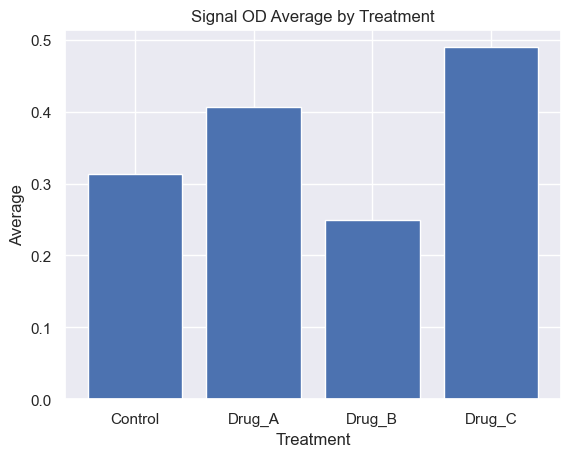

In [59]:
signal_mean_by_treatment = df.groupby("Treatment")["Signal_OD"].mean()
plt.bar(signal_mean_by_treatment.index, signal_mean_by_treatment.values)
plt.title("Signal OD Average by Treatment")
plt.xlabel("Treatment")
plt.ylabel("Average")
plt.show()

### Exercise 3: Create a Matplotlib histogram of signal values (1 point)

Instructions:

1. Make a histogram using the `Signal_OD` column.  
2. Use 5 bins.  
3. Add a title and label both axes.


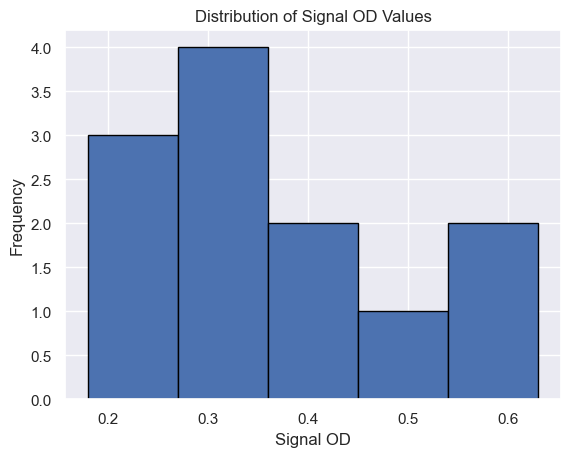

In [46]:
plt.hist(signal_OD, bins=5, edgecolor="black")
plt.title('Distribution of Signal OD Values')
plt.xlabel("Signal OD")
plt.ylabel("Frequency")
plt.show()

### Exercise 4: Create a Seaborn scatter plot (2 points)

Instructions:

1. Make a Seaborn scatter plot with `Time_min` on the x-axis.  
2. Use `Signal_OD` on the y-axis.  
3. Use `Treatment` as the `hue`.  
4. Add a title and label both axes.


Text(0, 0.5, 'Signal OD')

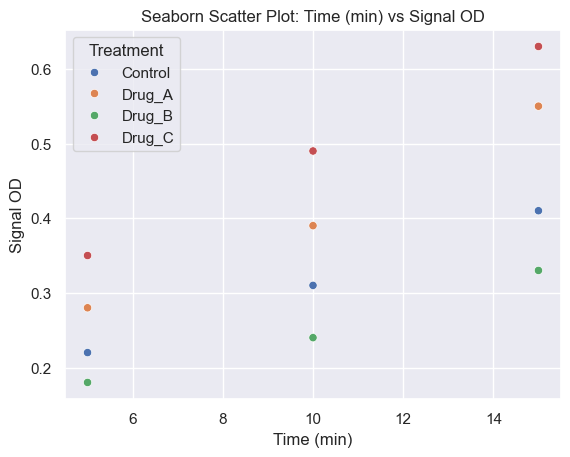

In [50]:
sns.scatterplot(data=df, x="Time_min", y="Signal_OD", hue="Treatment")
plt.title("Seaborn Scatter Plot: Time (min) vs Signal OD")
plt.xlabel('Time (min)')
plt.ylabel("Signal OD")

### Exercise 5: Create a Seaborn box plot (2 points)

Instructions:

1. Make a Seaborn box plot showing `Signal_OD` for each `Treatment`.  
2. Add a title and label both axes.


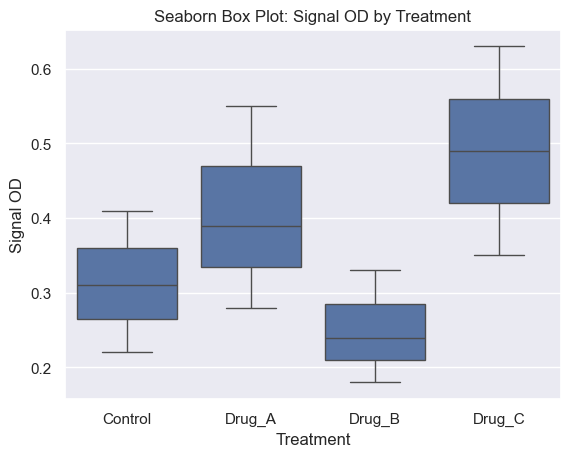

In [52]:
sns.boxplot(data=df, x="Treatment", y="Signal_OD")
plt.title("Seaborn Box Plot: Signal OD by Treatment")
plt.ylabel("Signal OD")
plt.show()

## Submission checklist

Before submitting your notebook, make sure you have:

- run all cells
- fixed any errors
- include your graphs
- labeled the axes on each graph
- saved your notebook
